# Imports

In [1]:
import pandas as pd
import numpy as np
from sklearn import model_selection, metrics
from sklearn import linear_model, ensemble
from sklearn.experimental import enable_hist_gradient_boosting
from sklearn.ensemble import HistGradientBoostingRegressor
import matplotlib.pyplot as plt

c:\mlops_lab_1\venv\Lib\site-packages\sklearn\experimental\enable_hist_gradient_boosting.py:18: UserWarning: Since version 1.0, it is not needed to import enable_hist_gradient_boosting anymore. HistGradientBoostingClassifier and HistGradientBoostingRegressor are now stable and can be normally imported from sklearn.ensemble.
  warnings.warn(


# Data Loading

In [2]:
features = pd.read_csv('../data/raw/features.csv.zip')
train = pd.read_csv('../data/raw/train.csv.zip')
stores = pd.read_csv('../data/raw/stores.csv')
test = pd.read_csv('../data/raw/test.csv.zip')

In [3]:
features.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [4]:
train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [5]:
test.head()

,Store,Dept,Date,IsHoliday
0,1,1,2012-11-02,False
1,1,1,2012-11-09,False
2,1,1,2012-11-16,False
3,1,1,2012-11-23,True
4,1,1,2012-11-30,False


In [6]:
stores.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [7]:
feature_store = features.merge(stores, how='inner', on = "Store")

In [8]:
train_df = train.merge(feature_store, how='inner', on = ['Store','Date','IsHoliday']).sort_values(by=['Store','Dept','Date']).reset_index(drop=True)

In [9]:
train_df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


In [10]:
test_df = test.merge(feature_store, how='inner', on = ['Store','Date','IsHoliday']).sort_values(by = ['Store','Dept','Date']).reset_index(drop=True)

In [11]:
feature_store = features.merge(stores, how='inner', on = "Store")
 
feature_store['Date'] = pd.to_datetime(feature_store['Date'])
train['Date'] = pd.to_datetime(train['Date'])
test['Date'] = pd.to_datetime(test['Date'])

feature_store['Day'] = feature_store['Date'].dt.day
feature_store['Week'] = feature_store['Date'].dt.isocalendar().week
feature_store['Month'] = feature_store['Date'].dt.month
feature_store['Year'] = feature_store['Date'].dt.year

In [12]:
train_df = train.merge(feature_store, how='inner', on = ['Store','Date','IsHoliday']).sort_values(by=['Store','Dept','Date']).reset_index(drop=True)

In [13]:
test_df = test.merge(feature_store, how='inner', on = ['Store','Date','IsHoliday']).sort_values(by = ['Store','Dept','Date']).reset_index(drop=True)

# EDA

In [14]:
numeric_df = train_df.select_dtypes(include='number')

numeric_df.describe().T.style.bar(subset=['mean'], color='#205ff2')\
                            .set_caption("Stats Summary of Numeric Variables")\
                            .background_gradient(subset=['min'], cmap='Reds')\
                            .background_gradient(subset=['max'], cmap='Greens')\
                            .background_gradient(subset=['std'], cmap='GnBu')\
                            .background_gradient(subset=['50%'], cmap='GnBu')

,count,mean,std,min,25%,50%,75%,max
Store,421570.000000,22.200546,12.785297,1.000000,11.000000,22.000000,33.000000,45.000000
Dept,421570.000000,44.260317,30.492054,1.000000,18.000000,37.000000,74.000000,99.000000
Weekly_Sales,421570.000000,15981.258123,22711.183519,-4988.940000,2079.650000,7612.030000,20205.852500,693099.360000
Temperature,421570.000000,60.090059,18.447931,-2.060000,46.680000,62.090000,74.280000,100.140000
Fuel_Price,421570.000000,3.361027,0.458515,2.472000,2.933000,3.452000,3.738000,4.468000
MarkDown1,150681.000000,7246.420196,8291.221345,0.270000,2240.270000,5347.450000,9210.900000,88646.760000
MarkDown2,111248.000000,3334.628621,9475.357325,-265.760000,41.600000,192.000000,1926.940000,104519.540000
MarkDown3,137091.000000,1439.421384,9623.078290,-29.100000,5.080000,24.600000,103.990000,141630.610000
MarkDown4,134967.000000,3383.168256,6292.384031,0.220000,504.220000,1481.310000,3595.040000,67474.850000
MarkDown5,151432.000000,4628.975079,5962.887455,135.160000,1878.440000,3359.450000,5563.800000,108519.280000


### Weekly sales

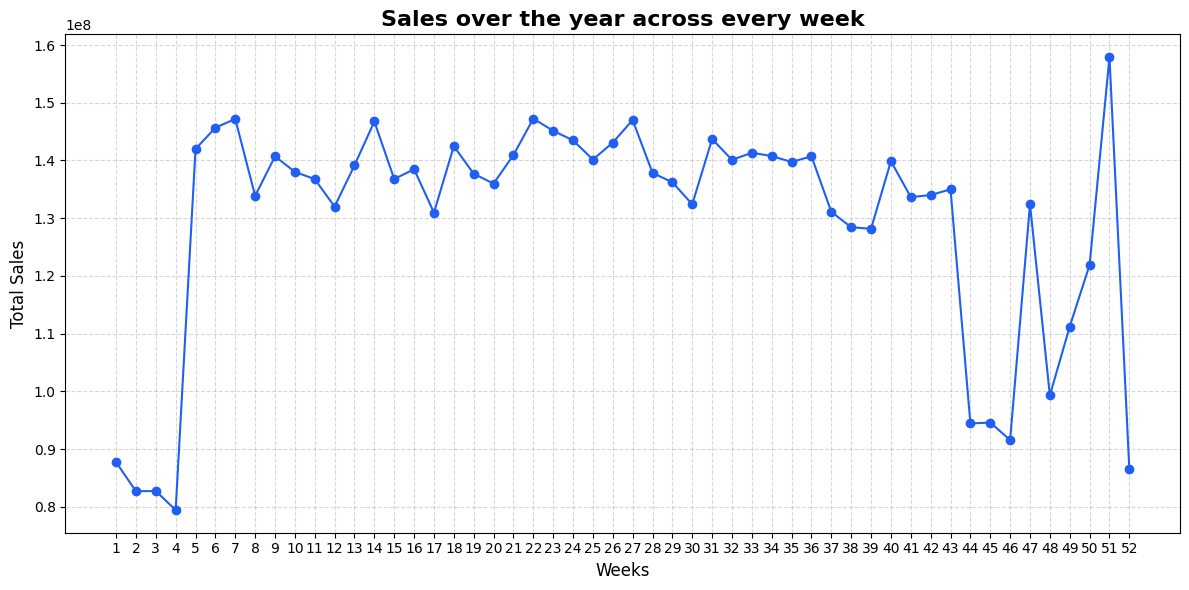

In [15]:
df_weeks = train_df.groupby('Week')['Weekly_Sales'].sum()

plt.figure(figsize=(12,6))
plt.plot(df_weeks.index, df_weeks.values, marker='o', color='#205ff2')
plt.title('Sales over the year across every week', fontsize=16, fontweight='bold')
plt.xlabel('Weeks', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.xticks(df_weeks.index)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Markdowns relationship with sales

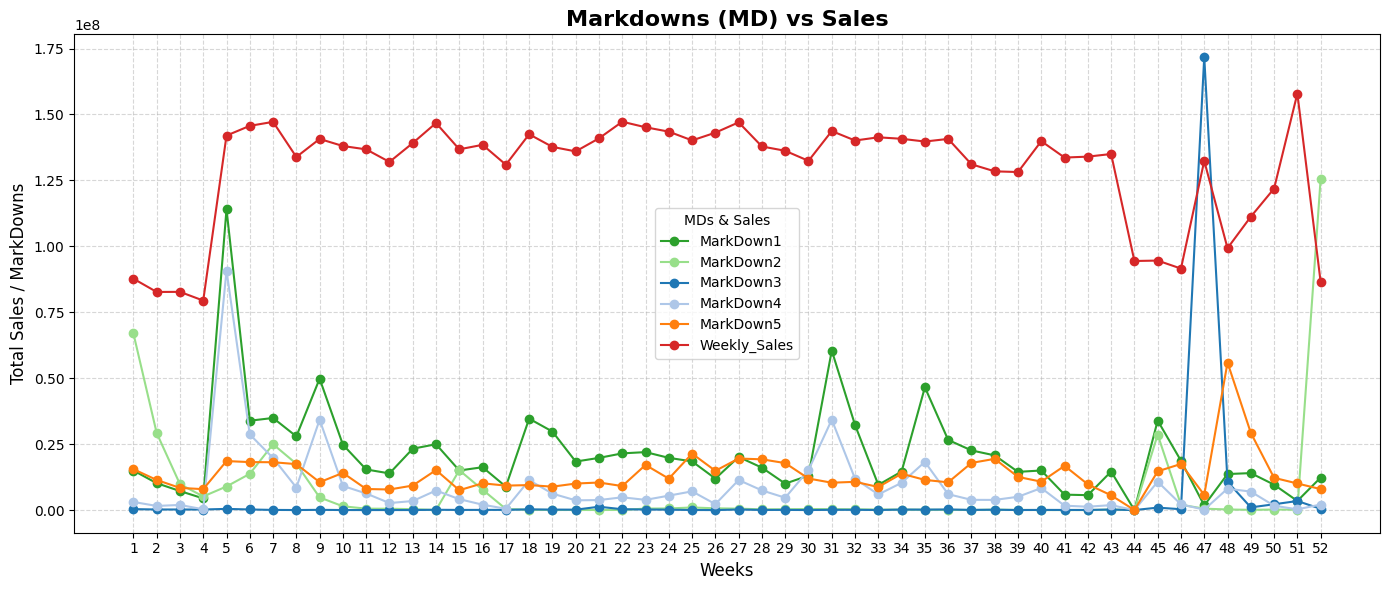

In [16]:
md_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
all_cols = md_cols + ['Weekly_Sales']

df_weeks = train_df.groupby('Week')[all_cols].sum()

plt.figure(figsize=(14,6))
colors = ['#2ca02c', '#98df8a', '#1f77b4', '#aec7e8', '#ff7f0e', '#d62728']

for col, color in zip(all_cols, colors):
    plt.plot(df_weeks.index, df_weeks[col], marker='o', color=color, label=col)

plt.title('Markdowns (MD) vs Sales', fontsize=16, fontweight='bold')
plt.xlabel('Weeks', fontsize=12)
plt.ylabel('Total Sales / MarkDowns', fontsize=12)
plt.xticks(df_weeks.index)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='MDs & Sales')
plt.tight_layout()
plt.show()

### Mean sales comparassion across the years

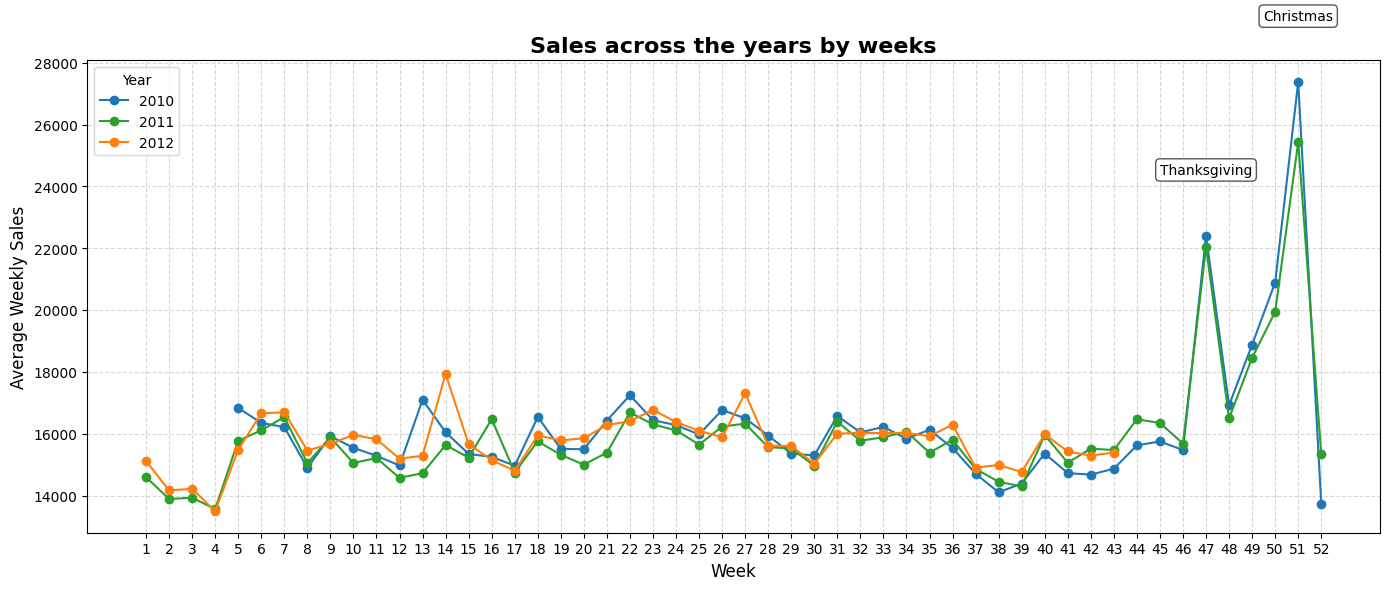

In [17]:
weekly_sales_data = {
    '2010': train_df.loc[train_df['Year']==2010].groupby('Week')['Weekly_Sales'].mean(),
    '2011': train_df.loc[train_df['Year']==2011].groupby('Week')['Weekly_Sales'].mean(),
    '2012': train_df.loc[train_df['Year']==2012].groupby('Week')['Weekly_Sales'].mean()
}

weekly_sales_df = pd.DataFrame(weekly_sales_data)
weekly_sales_df_sorted = weekly_sales_df.sort_index()

plt.figure(figsize=(14,6))
colors = ['#1f77b4', '#2ca02c', '#ff7f0e']

for col, color in zip(weekly_sales_df_sorted.columns, colors):
    plt.plot(weekly_sales_df_sorted.index, weekly_sales_df_sorted[col], marker='o', color=color, label=col)

plt.title('Sales across the years by weeks', fontsize=16, fontweight='bold')
plt.xlabel('Week', fontsize=12)
plt.ylabel('Average Weekly Sales', fontsize=12)
plt.xticks(weekly_sales_df_sorted.index)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Year')

plt.annotate('Thanksgiving', xy=(47, weekly_sales_df_sorted.loc[47].max()), 
             xytext=(47, weekly_sales_df_sorted.loc[47].max() + 2000),
             bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#585858'), ha='center')

plt.annotate('Christmas', xy=(51, weekly_sales_df_sorted.loc[51].max()), 
             xytext=(51, weekly_sales_df_sorted.loc[51].max() + 2000),
             bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#585858'), ha='center')

plt.tight_layout()
plt.show()

### Store Sizes, Types & Sales

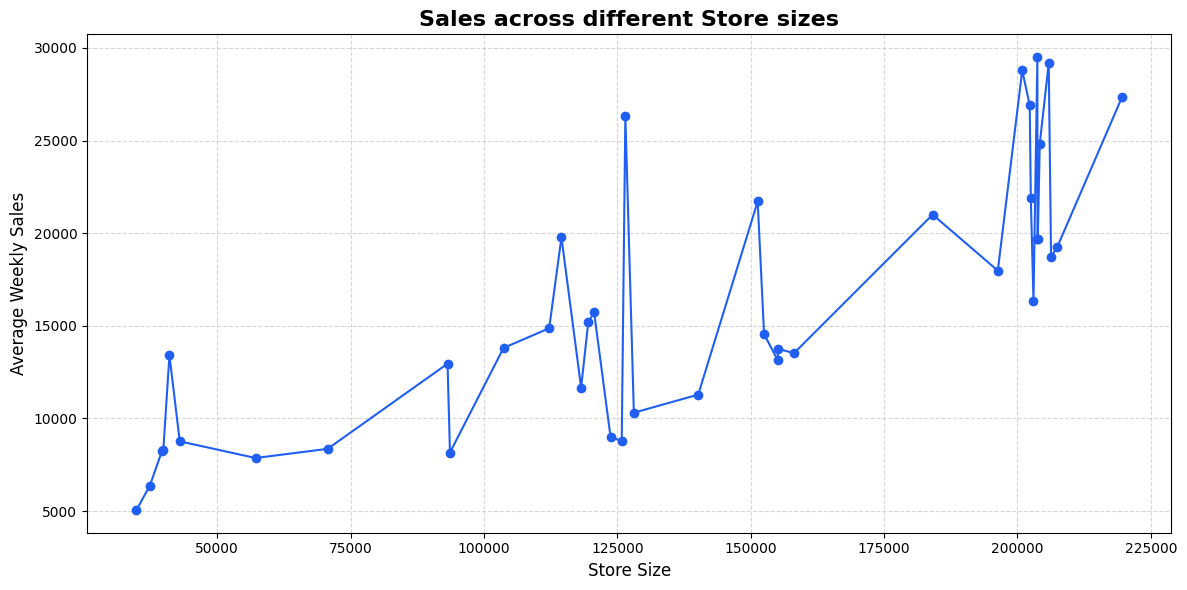

In [18]:
import matplotlib.pyplot as plt

sizes = train_df.groupby('Size')['Weekly_Sales'].mean()

plt.figure(figsize=(12,6))
plt.plot(sizes.index, sizes.values, marker='o', color='#205ff2')

plt.title('Sales across different Store sizes', fontsize=16, fontweight='bold')
plt.xlabel('Store Size', fontsize=12)
plt.ylabel('Average Weekly Sales', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

C:\Users\Андрій\AppData\Local\Temp\ipykernel_8612\1950755474.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=store_types, patch_artist=True,


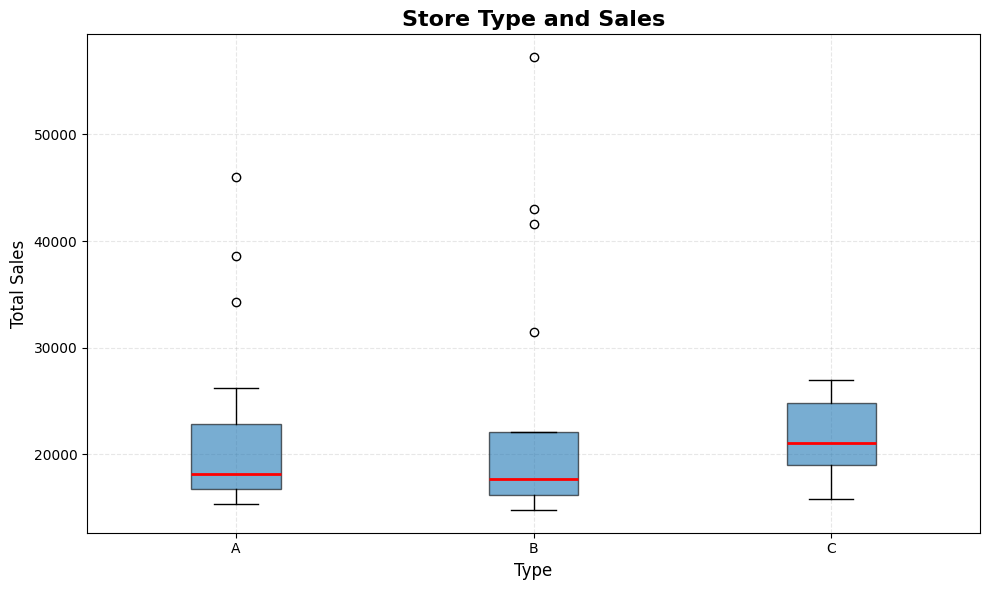

In [19]:
store_sale = pd.concat([stores['Type'], train_df['Weekly_Sales']], axis=1).dropna(subset=['Type', 'Weekly_Sales'])

store_types = store_sale['Type'].unique()

data = [store_sale.loc[store_sale['Type'] == t, 'Weekly_Sales'] for t in store_types]

plt.figure(figsize=(10,6))

plt.boxplot(data, labels=store_types, patch_artist=True,
            boxprops=dict(facecolor='#1f77b4', color='black', alpha=0.6),
            medianprops=dict(color='red', linewidth=2),
            whiskerprops=dict(color='black'),
            capprops=dict(color='black'))

plt.title('Store Type and Sales', fontsize=16, fontweight='bold')
plt.xlabel('Type', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Heatmap and correlation between features

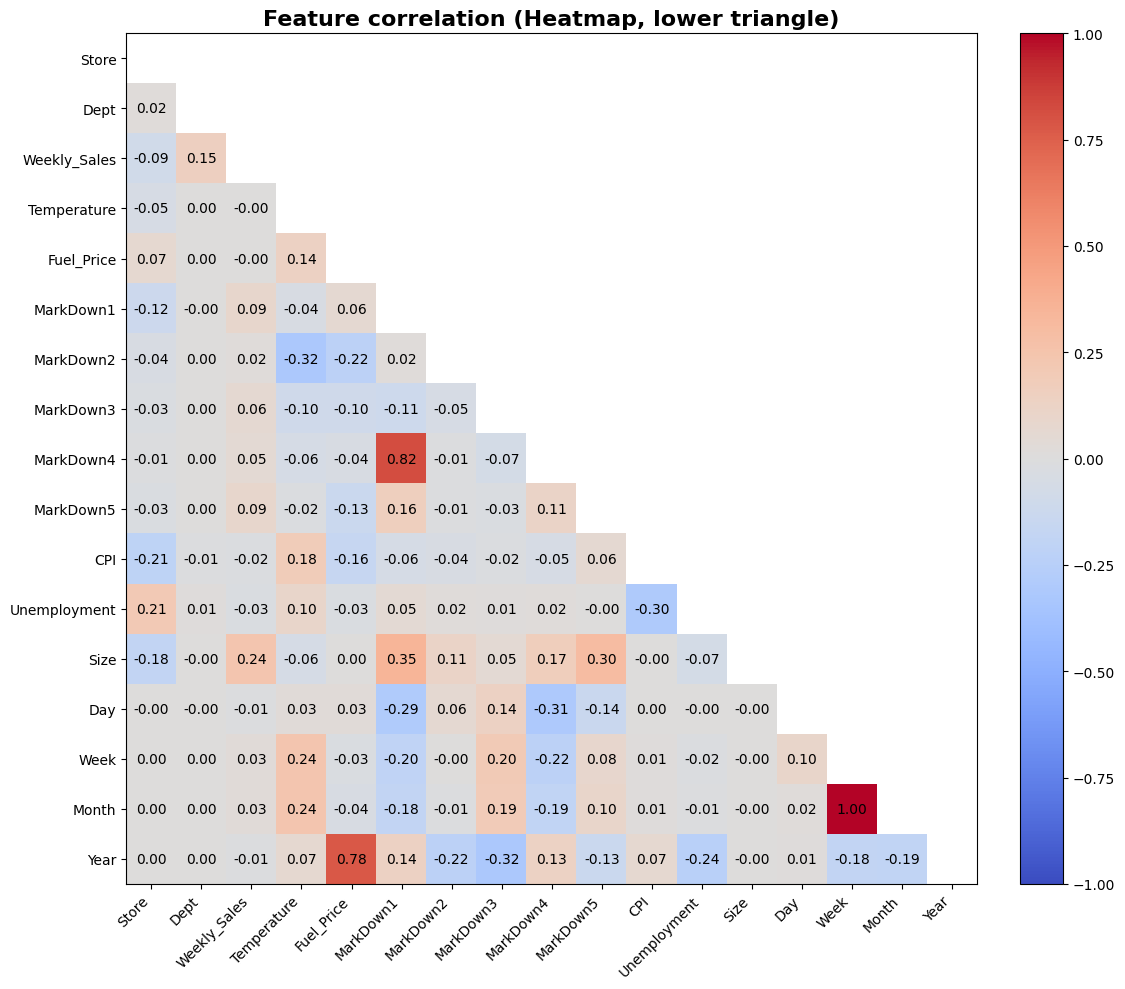

In [20]:
numeric_df = train_df.select_dtypes(include=np.number)

corr = numeric_df.corr().round(2).to_numpy()
labels = numeric_df.columns.tolist()

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12,10))

corr_masked = np.copy(corr)
corr_masked[mask] = np.nan

cax = ax.imshow(corr_masked, cmap='coolwarm', vmin=-1, vmax=1)

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        if not mask[i, j]: 
            ax.text(j, i, f"{corr[i, j]:.2f}", ha='center', va='center', color='black')

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticklabels(labels)

fig.colorbar(cax, fraction=0.046, pad=0.04)

plt.title('Feature correlation (Heatmap, lower triangle)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

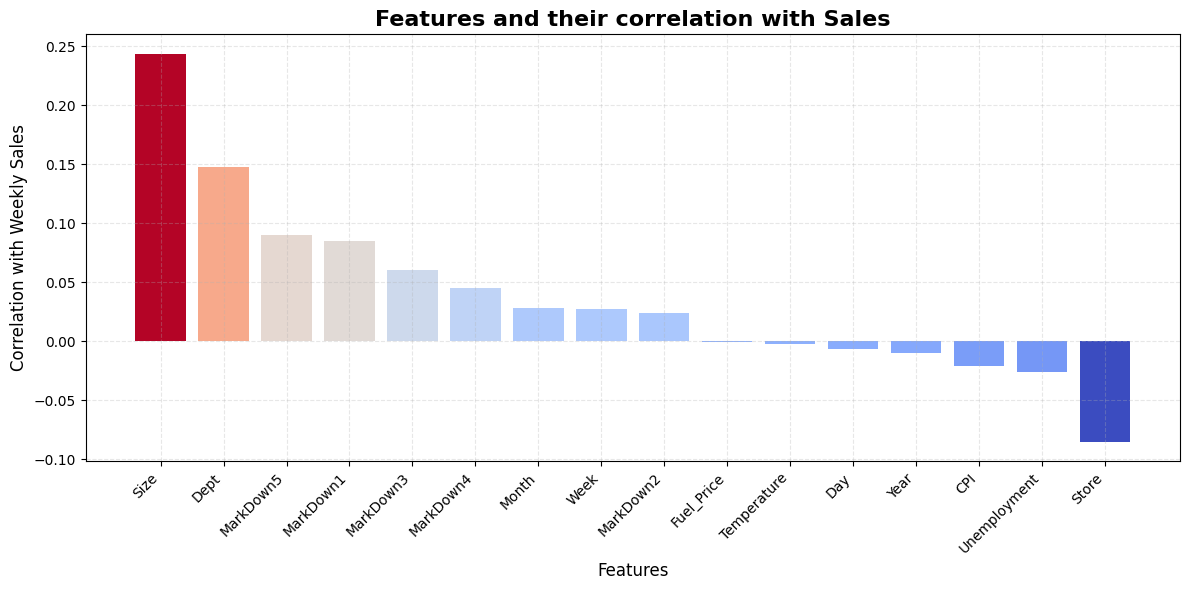

In [21]:
weekly_sales_corr = train_df.select_dtypes(include=np.number).corr()['Weekly_Sales'].drop('Weekly_Sales')
corr_df = weekly_sales_corr.sort_values(ascending=False)

norm = plt.Normalize(corr_df.min(), corr_df.max())
colors = plt.cm.coolwarm(norm(corr_df.values))

plt.figure(figsize=(12,6))
plt.bar(corr_df.index, corr_df.values, color=colors)

plt.title('Features and their correlation with Sales', fontsize=16, fontweight='bold')
plt.xlabel('Features', fontsize=12)
plt.ylabel('Correlation with Weekly Sales', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Missing values exploration

In [22]:
train_df.isna().sum()[train_df.isna().sum() > 0].sort_values(ascending=False)

MarkDown2    310322
MarkDown4    286603
MarkDown3    284479
MarkDown1    270889
MarkDown5    270138
dtype: int64

In [23]:
test_df.isna().sum()[test_df.isna().sum() > 0].sort_values(ascending=False)

CPI             38162
Unemployment    38162
MarkDown2       28627
MarkDown4       12888
MarkDown3        9829
MarkDown1         149
dtype: int64